# SCRIPT 1 - Regresi Linear
# Model: MLR_B2B3 → X = [B2, B3], SLR_B2 → X = [B2], SLR_B3 → X = [B3]
# Y: Kelembaban tanah

## Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Import Library

In [2]:
import os
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

## 1. Konfigurasi path data dan hasil

In [3]:
PATH_LAPANG  = '/content/drive/MyDrive/Skripsi/Data Lapang/Hasil_Lapangan.csv'
PATH_CITRA_A = '/content/drive/MyDrive/Skripsi/Data Citra/kelompokA_10m_Mei2026_modified.csv'

OUT_DIR = '/content/drive/MyDrive/Skripsi/Hasil Pemodelan Baru/MLR/'
os.makedirs(OUT_DIR, exist_ok=True)

print(f'Output disimpan ke: {OUT_DIR}')

Output disimpan ke: /content/drive/MyDrive/Skripsi/Hasil Pemodelan Baru/MLR/


## 2. Load dan gabung data CSV

In [4]:
df_lapang = pd.read_csv(PATH_LAPANG)
df_A      = pd.read_csv(PATH_CITRA_A)

df_merged = pd.merge(
    df_lapang[['Titik_Pengamatan', 'Kelembaban (%)']],
    df_A[['Titik_Pengamatan', 'B2', 'B3']],
    on='Titik_Pengamatan'
).dropna()

print('=' * 55)
print('DATA SETELAH MERGE')
print('=' * 55)
print(f'Jumlah sampel valid : {df_merged.shape[0]}')
print(f'Kolom               : {list(df_merged.columns)}')
print()
print('Statistik deskriptif:')
print(df_merged[['B2', 'B3', 'Kelembaban (%)']].describe().round(4).to_string())

DATA SETELAH MERGE
Jumlah sampel valid : 42
Kolom               : ['Titik_Pengamatan', 'Kelembaban (%)', 'B2', 'B3']

Statistik deskriptif:
            B2       B3  Kelembaban (%)
count  42.0000  42.0000         42.0000
mean    0.0590   0.0880         73.7714
std     0.0206   0.0173         15.4912
min     0.0137   0.0520         34.9000
25%     0.0405   0.0744         69.2750
50%     0.0643   0.0878         76.6000
75%     0.0741   0.1028         83.6750
max     0.0950   0.1306         94.9000


## 3. Cek Asumsi MLR

In [5]:
# MLR punya asumsi yang perlu dicek sebelum modeling
# Khususnya normalitas Y — karena kita tidak lagi pakai transformasi

Y_raw = df_merged['Kelembaban (%)'].values

print('=' * 55)
print('CEK ASUMSI MLR')
print('=' * 55)

# Normalitas Y
w, p = stats.shapiro(Y_raw)
print(f'\n1. Normalitas Y (Shapiro-Wilk):')
print(f'   W={w:.4f}, p={p:.4f}',
      '✓ Normal' if p > 0.05 else '✗ Tidak Normal — asumsi MLR terlanggar')

# Skewness
sk = stats.skew(Y_raw)
print(f'   Skewness = {sk:.3f}',
      '(mendekati simetris)' if abs(sk) < 0.5
      else '(miring sedang)' if abs(sk) < 1.0
      else '(sangat miring — perlu diperhatikan)')

print(f'\n2. Multikolinearitas B2 vs B3:')
r_b2b3, p_b2b3 = stats.pearsonr(df_merged['B2'], df_merged['B3'])
print(f'   Korelasi B2-B3 : r={r_b2b3:.4f}, p={p_b2b3:.4f}')
if abs(r_b2b3) > 0.8:
    print('   ⚠ Korelasi sangat tinggi — multikolinearitas bermasalah untuk MLR')
    print('   → Koefisien B2 dan B3 tidak stabil, interpretasi individual tidak valid')
elif abs(r_b2b3) > 0.5:
    print('   ⚠ Korelasi sedang — multikolinearitas perlu diwaspadai')
else:
    print('   ✓ Korelasi rendah — multikolinearitas tidak bermasalah')

print(f'\nCatatan: MLR murni tidak memiliki regularisasi.')
print(f'Jika asumsi terlanggar, hasil koefisien perlu diinterpretasi dengan hati-hati.')

CEK ASUMSI MLR

1. Normalitas Y (Shapiro-Wilk):
   W=0.9097, p=0.0028 ✗ Tidak Normal — asumsi MLR terlanggar
   Skewness = -0.985 (miring sedang)

2. Multikolinearitas B2 vs B3:
   Korelasi B2-B3 : r=0.9162, p=0.0000
   ⚠ Korelasi sangat tinggi — multikolinearitas bermasalah untuk MLR
   → Koefisien B2 dan B3 tidak stabil, interpretasi individual tidak valid

Catatan: MLR murni tidak memiliki regularisasi.
Jika asumsi terlanggar, hasil koefisien perlu diinterpretasi dengan hati-hati.


## 4. Fungsi Training MLR

In [6]:
KF5  = KFold(n_splits=5,  shuffle=True, random_state=42)
KF10 = KFold(n_splits=10, shuffle=True, random_state=42)

def train_mlr(X, Y_raw, label, bands, out_path, df_merged, kf, kf_label):
    print(f"\n{'=' * 55}")
    print(f"MODEL  : {label}")
    print(f"Band   : {bands}")
    print(f"CV     : {kf_label}")
    print(f"{'=' * 55}")

    model  = LinearRegression()
    Y_pred = cross_val_predict(model, X, Y_raw, cv=kf)
    Y_pred = np.clip(Y_pred, 0, 100)

    # Metrik
    rmse = np.sqrt(mean_squared_error(Y_raw, Y_pred))
    mae  = mean_absolute_error(Y_raw, Y_pred)
    r2   = r2_score(Y_raw, Y_pred)
    rpd  = np.std(Y_raw) / rmse

    print(f"\nMETRIK PERFORMA (skala asli %):")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  MAE  : {mae:.4f}")
    print(f"  R²   : {r2:.4f}")
    print(f"  RPD  : {rpd:.4f}  "
          f"{'(tidak layak)' if rpd < 1.5 else '(estimasi kasar)' if rpd < 2.0 else '(reliable)'}")

    # Fit ulang semua data untuk koefisien dan intersep (pelaporan)
    model_full = LinearRegression()
    model_full.fit(X, Y_raw)
    coef_df = pd.DataFrame({
        'Band'      : bands,
        'Koefisien' : model_full.coef_,
        'Abs'       : np.abs(model_full.coef_)
    }).sort_values('Abs', ascending=False)

    print(f"\nPERSAMAAN REGRESI:")
    print(f"  Intersep : {model_full.intercept_:.4f}")
    for _, row in coef_df.iterrows():
        print(f"  {row['Band']:5s}    : {row['Koefisien']:+.4f}")

    persamaan = f"Y = {model_full.intercept_:.4f}"
    for _, row in coef_df.sort_values('Band').iterrows():
        persamaan += f" + ({row['Koefisien']:+.4f} × {row['Band']})"
    print(f"\n  → {persamaan}")

    print(f"\nKOEFISIEN (diurutkan kontribusi):")
    print(coef_df.to_string(index=False))

    # Simpan CSV
    safe = f"{label}_{kf_label}".replace(' ', '_').replace('(', '').replace(')', '')

    pd.DataFrame({
        'Titik_Pengamatan'   : df_merged['Titik_Pengamatan'].values,
        'Kelembaban_Aktual'  : Y_raw,
        'Kelembaban_Prediksi': Y_pred,
        'Residual'           : Y_raw - Y_pred
    }).to_csv(out_path + f'prediksi_{safe}.csv', index=False)

    coef_df['Intersep'] = model_full.intercept_
    coef_df.to_csv(out_path + f'koefisien_{safe}.csv', index=False)

    pd.DataFrame([{
        'Model' : label,
        'CV'    : kf_label,
        'Band'  : str(bands),
        'RMSE'  : round(rmse, 4),
        'MAE'   : round(mae,  4),
        'R2'    : round(r2,   4),
        'RPD'   : round(rpd,  4),
        'Intersep': round(model_full.intercept_, 4),
        **{f'Koef_{b}': round(c, 4)
           for b, c in zip(bands, model_full.coef_)}
    }]).to_csv(out_path + f'metrik_{safe}.csv', index=False)

    # Visualisasi
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(f'MLR — {label} ({kf_label})', fontsize=13, fontweight='bold')

    ax = axes[0]
    ax.scatter(Y_raw, Y_pred, alpha=0.7, color='steelblue',
               edgecolors='white', s=60)
    lo = min(Y_raw.min(), Y_pred.min()) - 2
    hi = max(Y_raw.max(), Y_pred.max()) + 2
    ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1.5, label='1:1 line')
    ax.set_xlabel('Kelembaban Aktual (%)', fontsize=11)
    ax.set_ylabel('Kelembaban Prediksi (%)', fontsize=11)
    ax.set_title(
        f'Aktual vs Prediksi\n'
        f'RMSE={rmse:.3f}  MAE={mae:.3f}  R²={r2:.3f}  RPD={rpd:.3f}'
    )
    ax.legend(); ax.grid(True, alpha=0.3)

    ax = axes[1]
    if len(bands) > 1:
        cp     = coef_df.sort_values('Koefisien')
        colors = ['tomato' if c < 0 else 'steelblue' for c in cp['Koefisien']]
        ax.barh(cp['Band'], cp['Koefisien'], color=colors, edgecolor='white')
        ax.axvline(0, color='black', linewidth=0.8)
        ax.set_xlabel('Nilai Koefisien', fontsize=11)
        ax.set_title('Koefisien per Band')
        ax.grid(True, alpha=0.3, axis='x')
    else:
        x_vals = X[:, 0]
        ax.scatter(x_vals, Y_raw, alpha=0.7, color='steelblue',
                   edgecolors='white', s=60)
        x_line = np.linspace(x_vals.min(), x_vals.max(), 100).reshape(-1, 1)
        y_line = model_full.predict(x_line)
        y_line = np.clip(y_line, 0, 100)
        ax.plot(x_line, y_line, 'r-', linewidth=2)
        ax.set_xlabel(f'{bands[0]}', fontsize=11)
        ax.set_ylabel('Kelembaban (%)', fontsize=11)
        ax.set_title(f'Scatter {bands[0]} vs Kelembaban\n(garis = regresi linear)')
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(
        out_path + f'grafik_{safe}.png',
        dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Output disimpan ke: {out_path}")

    return {
        'label': label, 'cv': kf_label, 'bands': str(bands),
        'rmse': rmse, 'mae': mae, 'r2': r2, 'rpd': rpd
    }

## 5. Define feature

In [7]:
Y_raw = df_merged['Kelembaban (%)'].values

# Catatan: MLR tidak wajib StandardScaler.
# B2 dan B3 berada dalam satuan yang sama (reflektansi 0–1),
# sehingga koefisien raw sudah dapat dibandingkan relatif antar band.
X_B2B3 = df_merged[['B2', 'B3']].values
X_B2   = df_merged[['B2']].values
X_B3   = df_merged[['B3']].values

print('Dimensi X per skenario:')
print(f'  B2+B3 : {X_B2B3.shape}')
print(f'  B2    : {X_B2.shape}')
print(f'  B3    : {X_B3.shape}')

Dimensi X per skenario:
  B2+B3 : (42, 2)
  B2    : (42, 1)
  B3    : (42, 1)


## 6. Running Model KFold 5


MODEL  : MLR_B2B3
Band   : ['B2', 'B3']
CV     : KFold-5

METRIK PERFORMA (skala asli %):
  RMSE : 12.8596
  MAE  : 10.2434
  R²   : 0.2941
  RPD  : 1.1902  (tidak layak)

PERSAMAAN REGRESI:
  Intersep : 113.3462
  B3       : -345.5095
  B2       : -155.2144

  → Y = 113.3462 + (-155.2144 × B2) + (-345.5095 × B3)

KOEFISIEN (diurutkan kontribusi):
Band   Koefisien        Abs
  B3 -345.509511 345.509511
  B2 -155.214420 155.214420


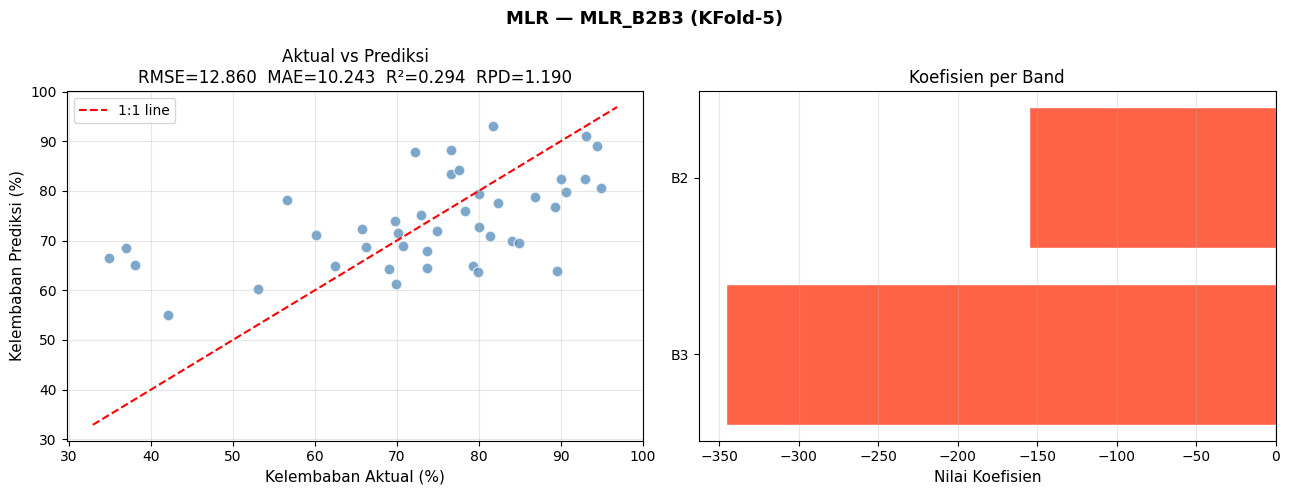

Output disimpan ke: /content/drive/MyDrive/Skripsi/Hasil Pemodelan Baru/MLR/

MODEL  : MLR_B2
Band   : ['B2']
CV     : KFold-5

METRIK PERFORMA (skala asli %):
  RMSE : 12.8914
  MAE  : 10.2122
  R²   : 0.2906
  RPD  : 1.1873  (tidak layak)

PERSAMAAN REGRESI:
  Intersep : 98.5932
  B2       : -420.5217

  → Y = 98.5932 + (-420.5217 × B2)

KOEFISIEN (diurutkan kontribusi):
Band   Koefisien        Abs
  B2 -420.521745 420.521745


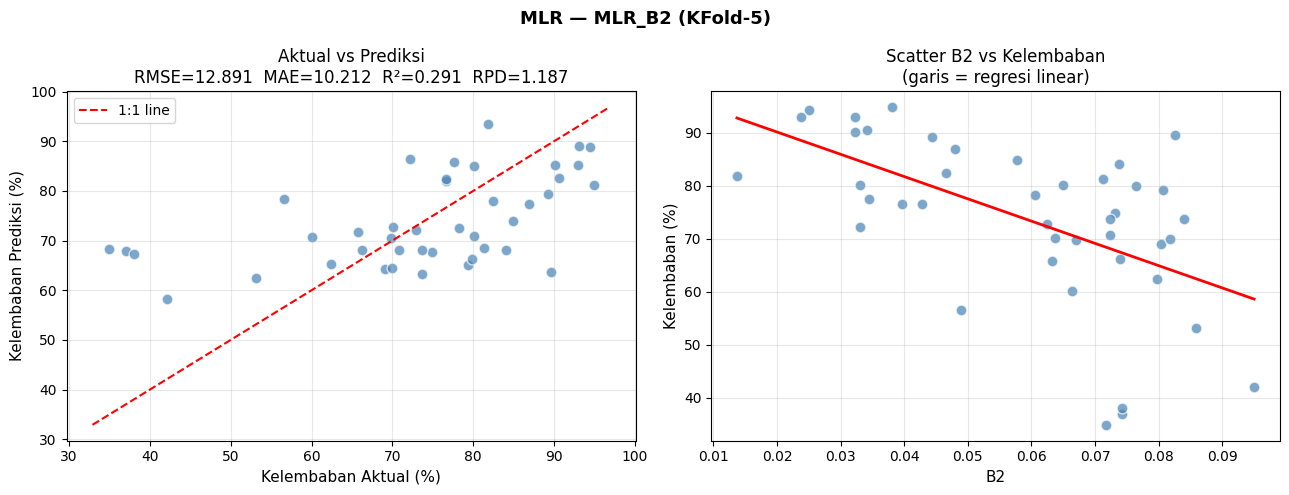

Output disimpan ke: /content/drive/MyDrive/Skripsi/Hasil Pemodelan Baru/MLR/

MODEL  : MLR_B3
Band   : ['B3']
CV     : KFold-5

METRIK PERFORMA (skala asli %):
  RMSE : 12.8549
  MAE  : 10.2882
  R²   : 0.2946
  RPD  : 1.1907  (tidak layak)

PERSAMAAN REGRESI:
  Intersep : 119.1202
  B3       : -515.1875

  → Y = 119.1202 + (-515.1875 × B3)

KOEFISIEN (diurutkan kontribusi):
Band  Koefisien       Abs
  B3 -515.18752 515.18752


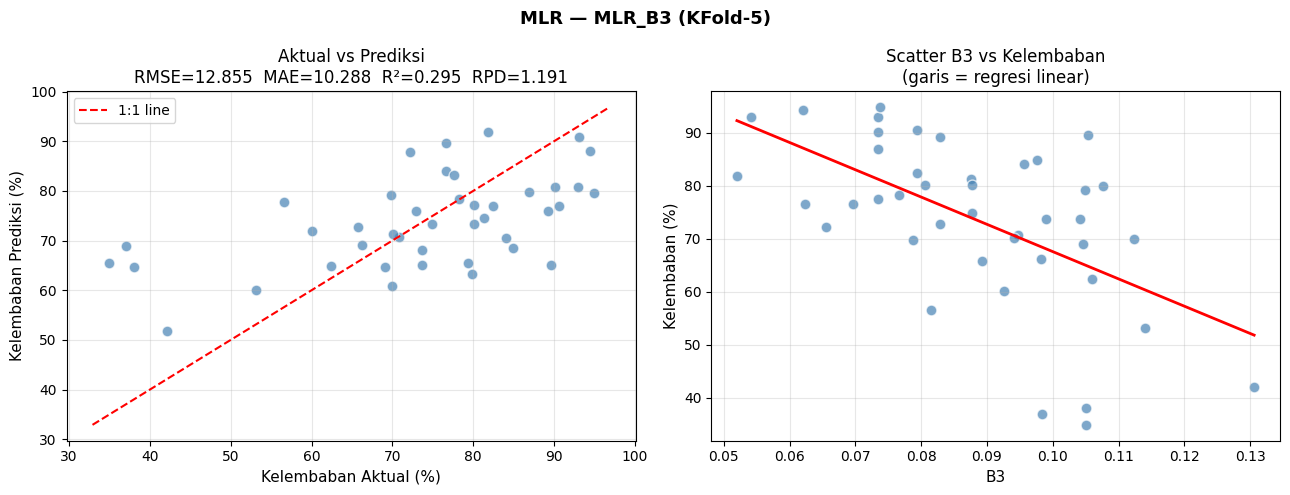

Output disimpan ke: /content/drive/MyDrive/Skripsi/Hasil Pemodelan Baru/MLR/


In [8]:
# --- KFold 5 ---
r_B2B3_kf5 = train_mlr(X_B2B3, Y_raw, 'MLR_B2B3', ['B2','B3'],
                        OUT_DIR, df_merged, KF5, 'KFold-5')
r_B2_kf5   = train_mlr(X_B2,   Y_raw, 'MLR_B2',   ['B2'],
                        OUT_DIR, df_merged, KF5, 'KFold-5')
r_B3_kf5   = train_mlr(X_B3,   Y_raw, 'MLR_B3',   ['B3'],
                        OUT_DIR, df_merged, KF5, 'KFold-5')

## 7. Running Model KFOld 10


MODEL  : MLR_B2B3
Band   : ['B2', 'B3']
CV     : KFold-10

METRIK PERFORMA (skala asli %):
  RMSE : 13.1335
  MAE  : 10.4716
  R²   : 0.2637
  RPD  : 1.1654  (tidak layak)

PERSAMAAN REGRESI:
  Intersep : 113.3462
  B3       : -345.5095
  B2       : -155.2144

  → Y = 113.3462 + (-155.2144 × B2) + (-345.5095 × B3)

KOEFISIEN (diurutkan kontribusi):
Band   Koefisien        Abs
  B3 -345.509511 345.509511
  B2 -155.214420 155.214420


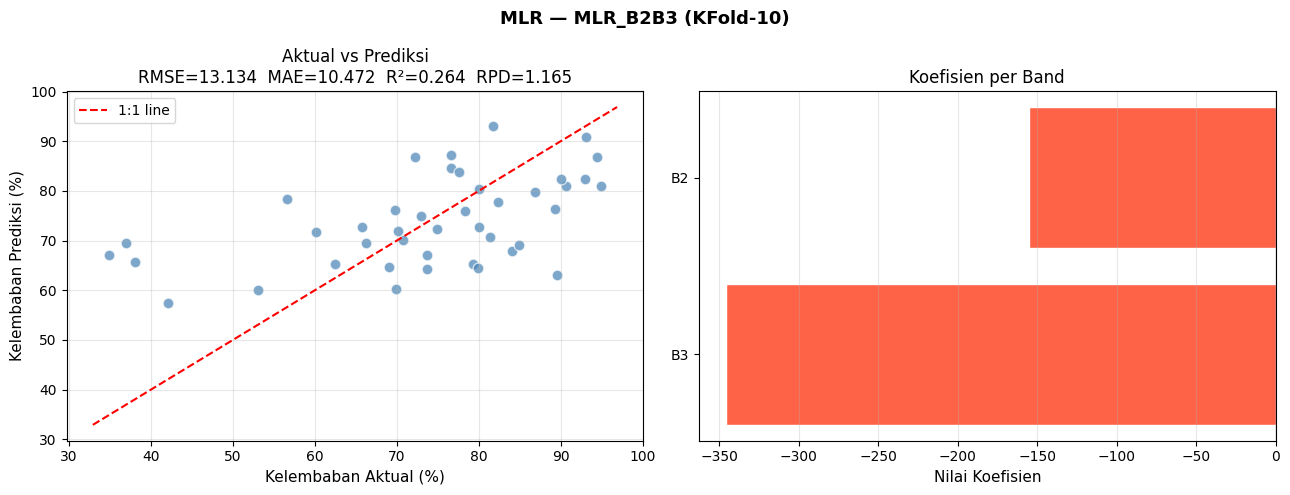

Output disimpan ke: /content/drive/MyDrive/Skripsi/Hasil Pemodelan Baru/MLR/

MODEL  : MLR_B2
Band   : ['B2']
CV     : KFold-10

METRIK PERFORMA (skala asli %):
  RMSE : 13.2264
  MAE  : 10.4533
  R²   : 0.2532
  RPD  : 1.1572  (tidak layak)

PERSAMAAN REGRESI:
  Intersep : 98.5932
  B2       : -420.5217

  → Y = 98.5932 + (-420.5217 × B2)

KOEFISIEN (diurutkan kontribusi):
Band   Koefisien        Abs
  B2 -420.521745 420.521745


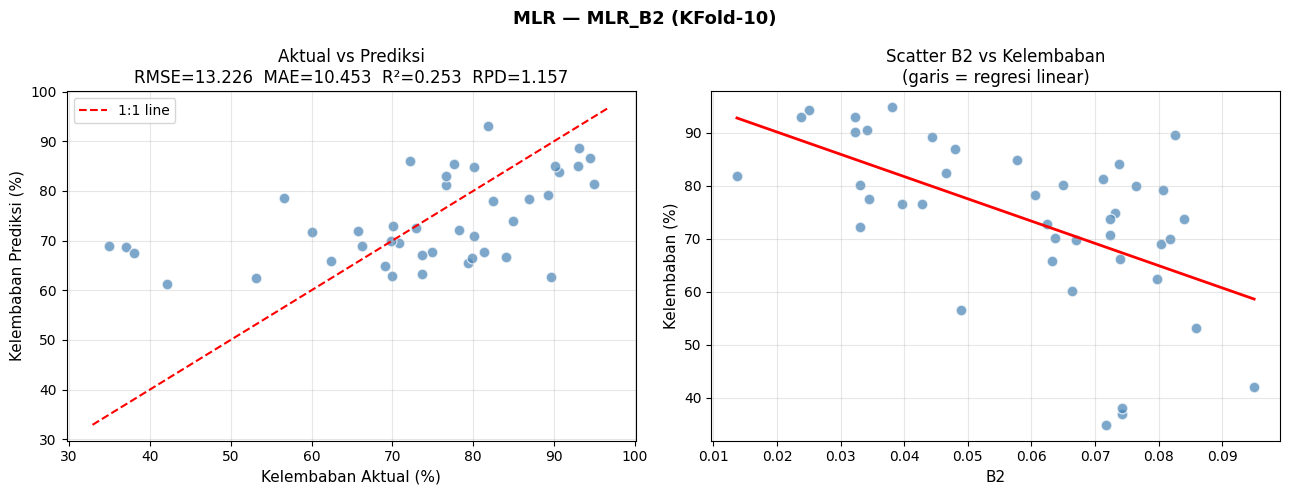

Output disimpan ke: /content/drive/MyDrive/Skripsi/Hasil Pemodelan Baru/MLR/

MODEL  : MLR_B3
Band   : ['B3']
CV     : KFold-10

METRIK PERFORMA (skala asli %):
  RMSE : 13.0597
  MAE  : 10.4909
  R²   : 0.2720
  RPD  : 1.1720  (tidak layak)

PERSAMAAN REGRESI:
  Intersep : 119.1202
  B3       : -515.1875

  → Y = 119.1202 + (-515.1875 × B3)

KOEFISIEN (diurutkan kontribusi):
Band  Koefisien       Abs
  B3 -515.18752 515.18752


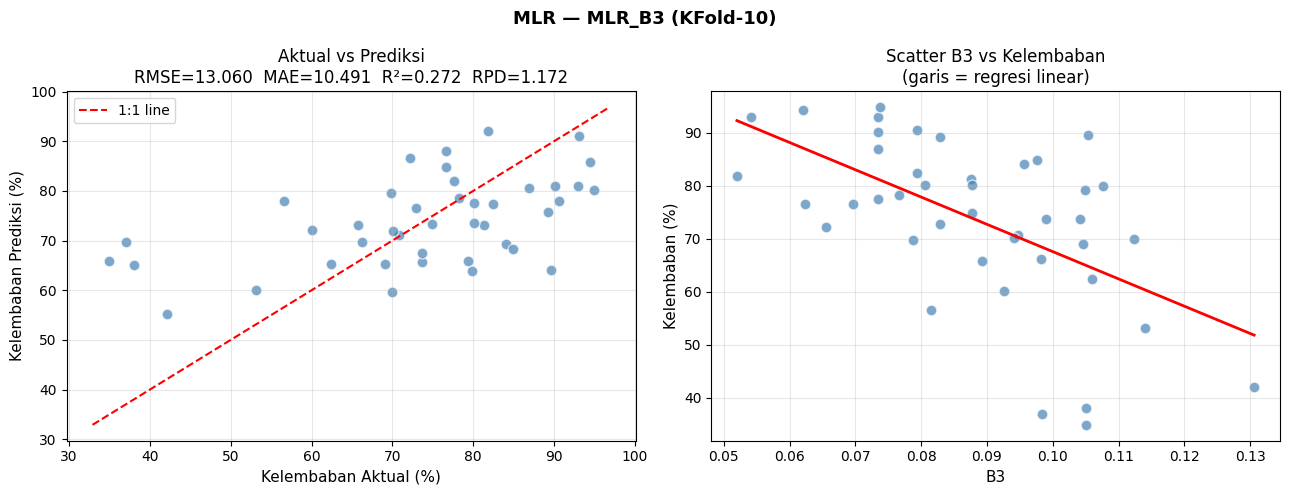

Output disimpan ke: /content/drive/MyDrive/Skripsi/Hasil Pemodelan Baru/MLR/


In [9]:
# --- KFold 10 ---
r_B2B3_kf10 = train_mlr(X_B2B3, Y_raw, 'MLR_B2B3', ['B2','B3'],
                         OUT_DIR, df_merged, KF10, 'KFold-10')
r_B2_kf10   = train_mlr(X_B2,   Y_raw, 'MLR_B2',   ['B2'],
                         OUT_DIR, df_merged, KF10, 'KFold-10')
r_B3_kf10   = train_mlr(X_B3,   Y_raw, 'MLR_B3',   ['B3'],
                         OUT_DIR, df_merged, KF10, 'KFold-10')

## 8. Ringkasan Perbandingan

In [10]:
print('\n' + '=' * 75)
print('RINGKASAN PERBANDINGAN MLR — KFold 5 vs KFold 10')
print('=' * 75)
print(f"{'Model':<15} {'CV':<10} {'Band':<12} {'RMSE':>8} {'MAE':>8} {'R²':>8} {'RPD':>8}")
print('-' * 75)

for r in [r_B2B3_kf5, r_B2_kf5, r_B3_kf5]:
    print(f"{r['label']:<15} {'KFold-5':<10} {r['bands']:<12} "
          f"{r['rmse']:>8.4f} {r['mae']:>8.4f} {r['r2']:>8.4f} {r['rpd']:>8.4f}")

print('-' * 75)

for r in [r_B2B3_kf10, r_B2_kf10, r_B3_kf10]:
    print(f"{r['label']:<15} {'KFold-10':<10} {r['bands']:<12} "
          f"{r['rmse']:>8.4f} {r['mae']:>8.4f} {r['r2']:>8.4f} {r['rpd']:>8.4f}")

print('\nInterpretasi RPD:')
print('  RPD < 1.5   → tidak layak untuk prediksi')
print('  RPD 1.5-2.0 → estimasi kasar, terbatas')
print('  RPD > 2.0   → reliable')

# Analisis stabilitas
print('\n' + '=' * 75)
print('ANALISIS STABILITAS KFold 5 vs KFold 10')
print('=' * 75)

pairs = [
    (r_B2B3_kf5, r_B2B3_kf10, 'MLR_B2B3'),
    (r_B2_kf5,   r_B2_kf10,   'MLR_B2'),
    (r_B3_kf5,   r_B3_kf10,   'MLR_B3'),
]

for r5, r10, nama in pairs:
    delta_r2   = abs(r5['r2']   - r10['r2'])
    delta_rmse = abs(r5['rmse'] - r10['rmse'])
    stabil     = 'STABIL ✓' if delta_r2 < 0.05 else 'TIDAK STABIL ⚠'
    print(f"\n  {nama}:")
    print(f"    ΔR²   = {delta_r2:.4f}  → {stabil}")
    print(f"    ΔRMSE = {delta_rmse:.4f}")

# Model terbaik
best_kf5  = max([r_B2B3_kf5,  r_B2_kf5,  r_B3_kf5],  key=lambda x: x['r2'])
best_kf10 = max([r_B2B3_kf10, r_B2_kf10, r_B3_kf10], key=lambda x: x['r2'])
print(f'\nModel terbaik KFold-5  : {best_kf5["label"]}  (R²={best_kf5["r2"]:.4f})')
print(f'Model terbaik KFold-10 : {best_kf10["label"]} (R²={best_kf10["r2"]:.4f})')

if best_kf5['label'] == best_kf10['label']:
    print('→ Model terbaik konsisten di kedua skema CV ✓')
else:
    print('→ Model terbaik berbeda antar skema CV ⚠')

# Simpan ringkasan
df_summary = pd.DataFrame([
    r_B2B3_kf5, r_B2_kf5, r_B3_kf5,
    r_B2B3_kf10, r_B2_kf10, r_B3_kf10
])
df_summary.to_csv(OUT_DIR + 'ringkasan_mlr_lengkap.csv', index=False)
print(f'\nRingkasan tersimpan: {OUT_DIR}ringkasan_mlr_lengkap.csv')
print('\nScript MLR selesai.')


RINGKASAN PERBANDINGAN MLR — KFold 5 vs KFold 10
Model           CV         Band             RMSE      MAE       R²      RPD
---------------------------------------------------------------------------
MLR_B2B3        KFold-5    ['B2', 'B3']  12.8596  10.2434   0.2941   1.1902
MLR_B2          KFold-5    ['B2']        12.8914  10.2122   0.2906   1.1873
MLR_B3          KFold-5    ['B3']        12.8549  10.2882   0.2946   1.1907
---------------------------------------------------------------------------
MLR_B2B3        KFold-10   ['B2', 'B3']  13.1335  10.4716   0.2637   1.1654
MLR_B2          KFold-10   ['B2']        13.2264  10.4533   0.2532   1.1572
MLR_B3          KFold-10   ['B3']        13.0597  10.4909   0.2720   1.1720

Interpretasi RPD:
  RPD < 1.5   → tidak layak untuk prediksi
  RPD 1.5-2.0 → estimasi kasar, terbatas
  RPD > 2.0   → reliable

ANALISIS STABILITAS KFold 5 vs KFold 10

  MLR_B2B3:
    ΔR²   = 0.0304  → STABIL ✓
    ΔRMSE = 0.2739

  MLR_B2:
    ΔR²   = 0.0374  → S

RESIDUAL DIAGNOSTICS — KFold-5 & KFold-10

────────────────────────────────────────────────────────────
  MODEL : MLR_B2B3  |  CV : KFold-5
────────────────────────────────────────────────────────────
  Shapiro-Wilk  : W=0.9517, p=0.0744  ✓ Residual normal
  Jarque-Bera   : stat=3.5175, p=0.1723  ✓ Normal
  Skewness      : -0.7021  (miring sedang)
  Excess Kurt   : 0.1951  (normal)


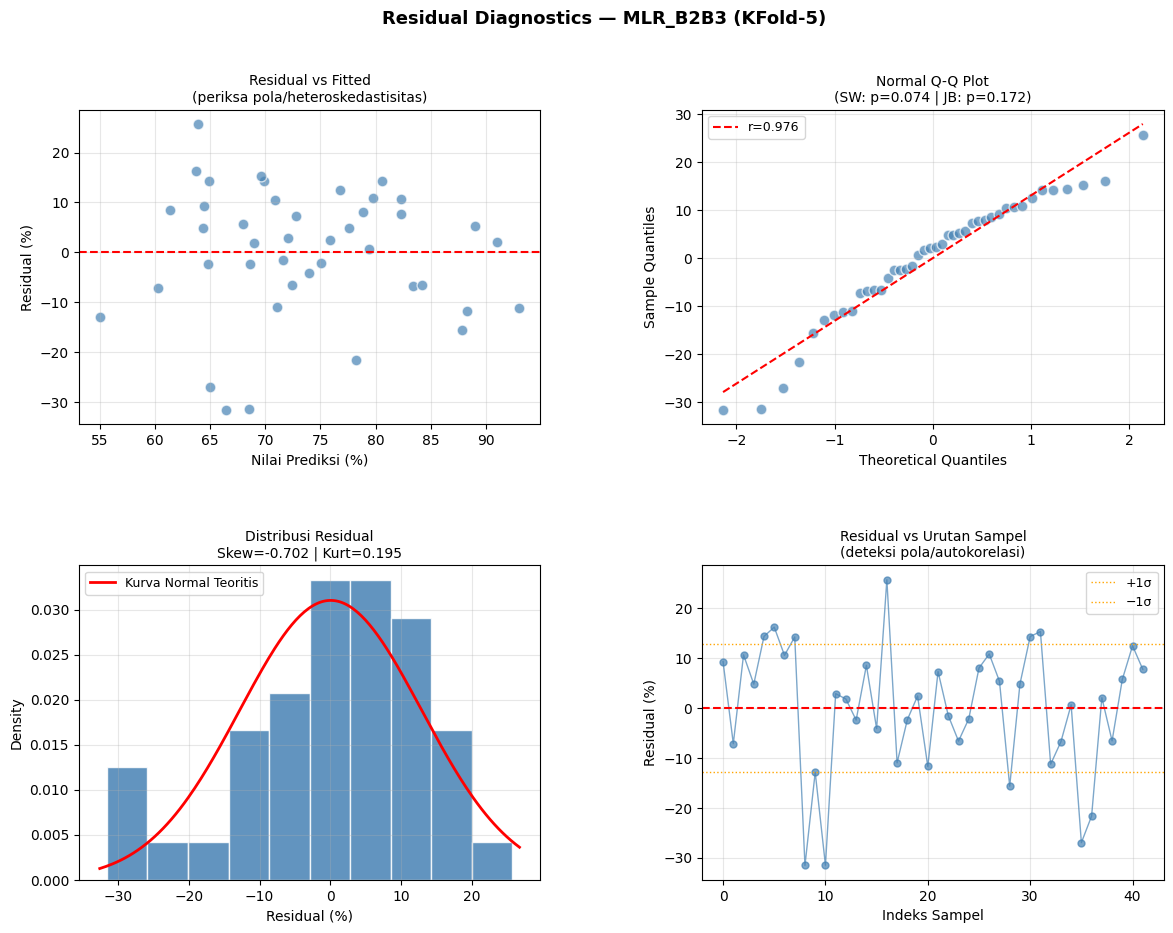


────────────────────────────────────────────────────────────
  MODEL : MLR_B2  |  CV : KFold-5
────────────────────────────────────────────────────────────
  Shapiro-Wilk  : W=0.9373, p=0.0230  ✗ Residual TIDAK normal
  Jarque-Bera   : stat=5.0941, p=0.0783  ✓ Normal
  Skewness      : -0.8239  (miring sedang)
  Excess Kurt   : 0.4423  (normal)


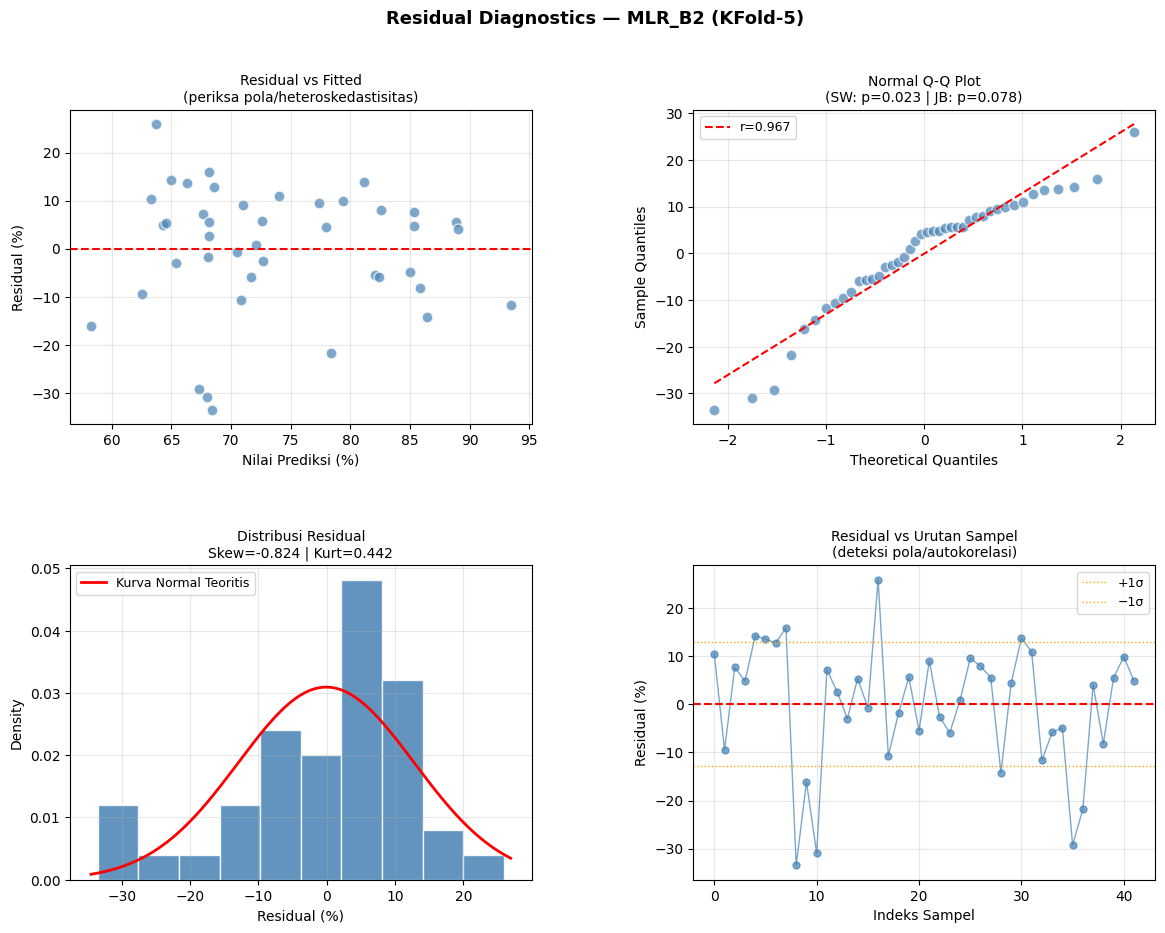


────────────────────────────────────────────────────────────
  MODEL : MLR_B3  |  CV : KFold-5
────────────────────────────────────────────────────────────
  Shapiro-Wilk  : W=0.9591, p=0.1369  ✓ Residual normal
  Jarque-Bera   : stat=2.9362, p=0.2304  ✓ Normal
  Skewness      : -0.6471  (miring sedang)
  Excess Kurt   : 0.0514  (normal)


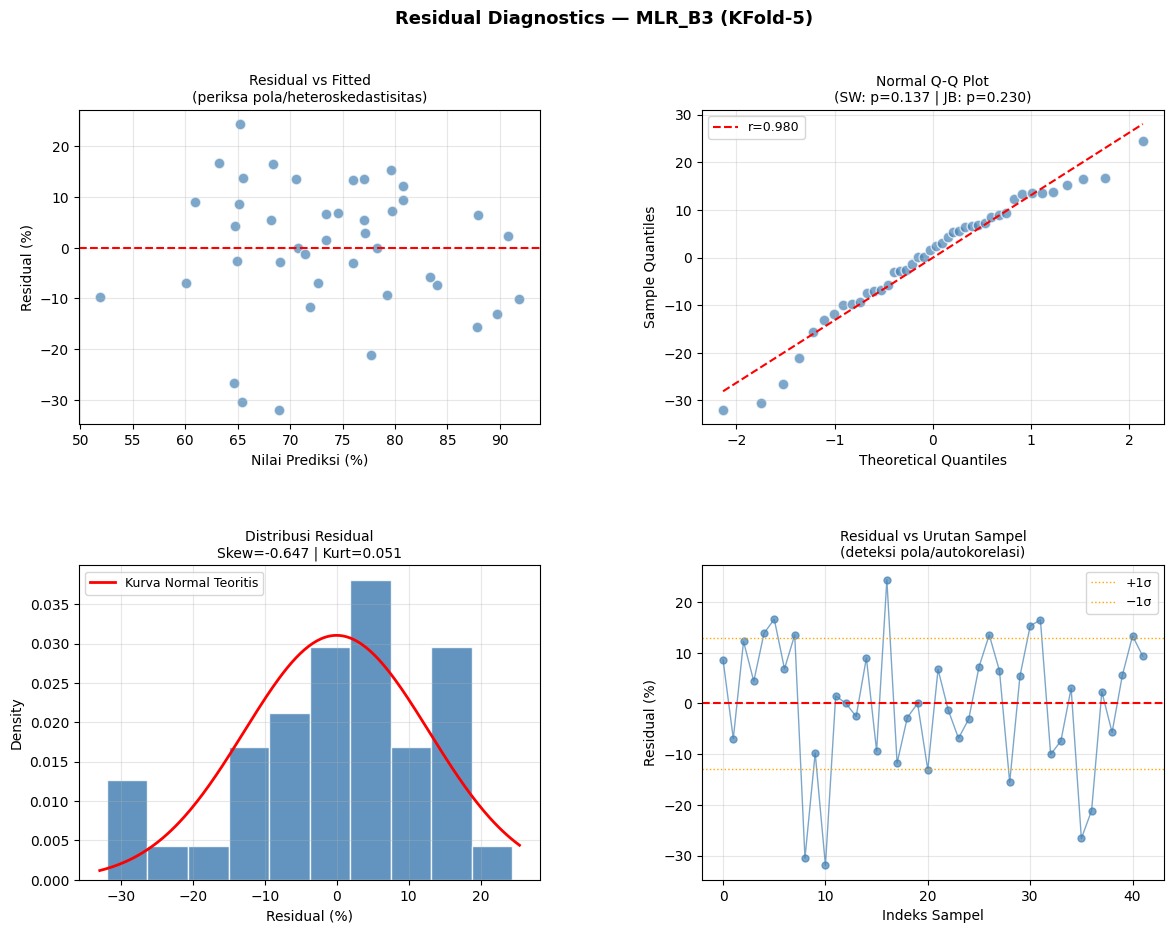


────────────────────────────────────────────────────────────
  MODEL : MLR_B2B3  |  CV : KFold-10
────────────────────────────────────────────────────────────
  Shapiro-Wilk  : W=0.9541, p=0.0904  ✓ Residual normal
  Jarque-Bera   : stat=3.2291, p=0.1990  ✓ Normal
  Skewness      : -0.6735  (miring sedang)
  Excess Kurt   : 0.1749  (normal)


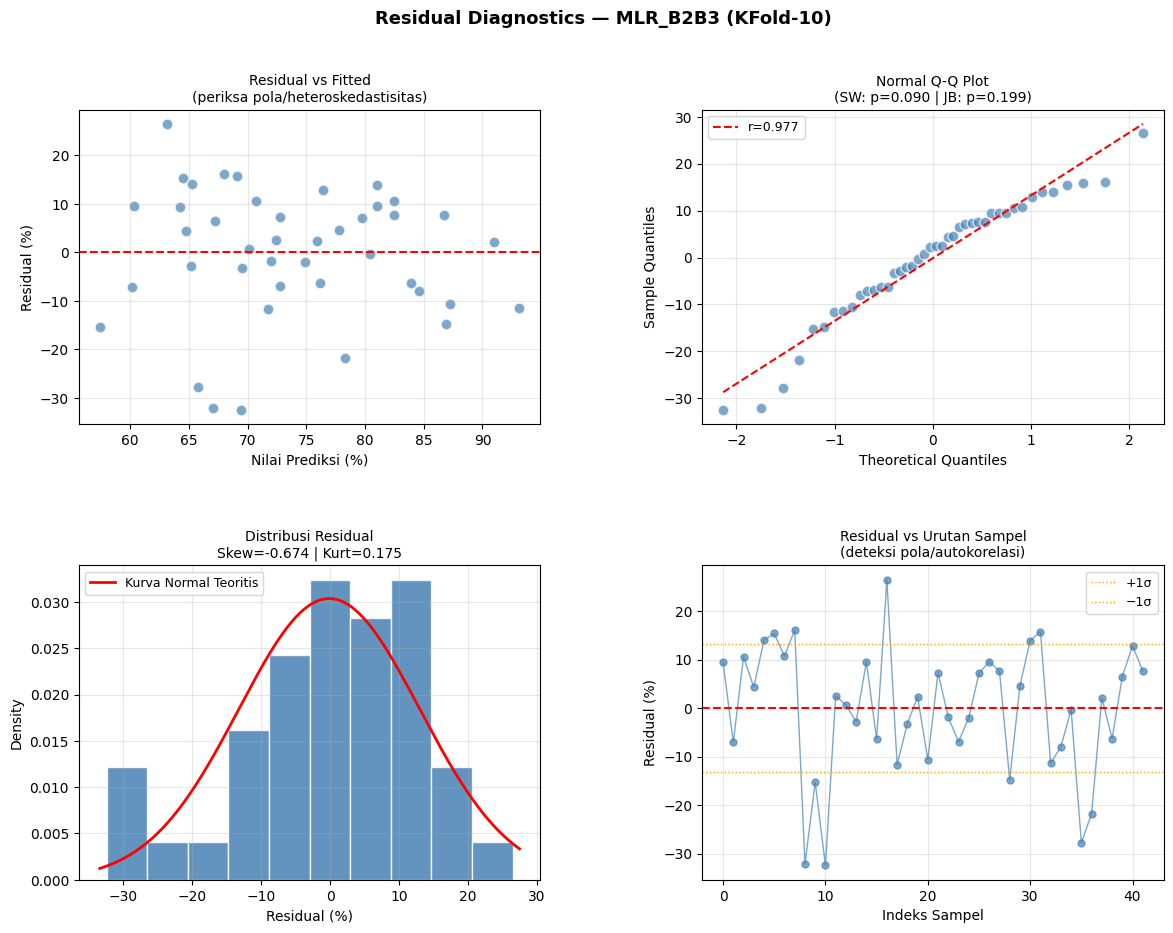


────────────────────────────────────────────────────────────
  MODEL : MLR_B2  |  CV : KFold-10
────────────────────────────────────────────────────────────
  Shapiro-Wilk  : W=0.9379, p=0.0241  ✗ Residual TIDAK normal
  Jarque-Bera   : stat=4.7838, p=0.0915  ✓ Normal
  Skewness      : -0.8007  (miring sedang)
  Excess Kurt   : 0.4114  (normal)


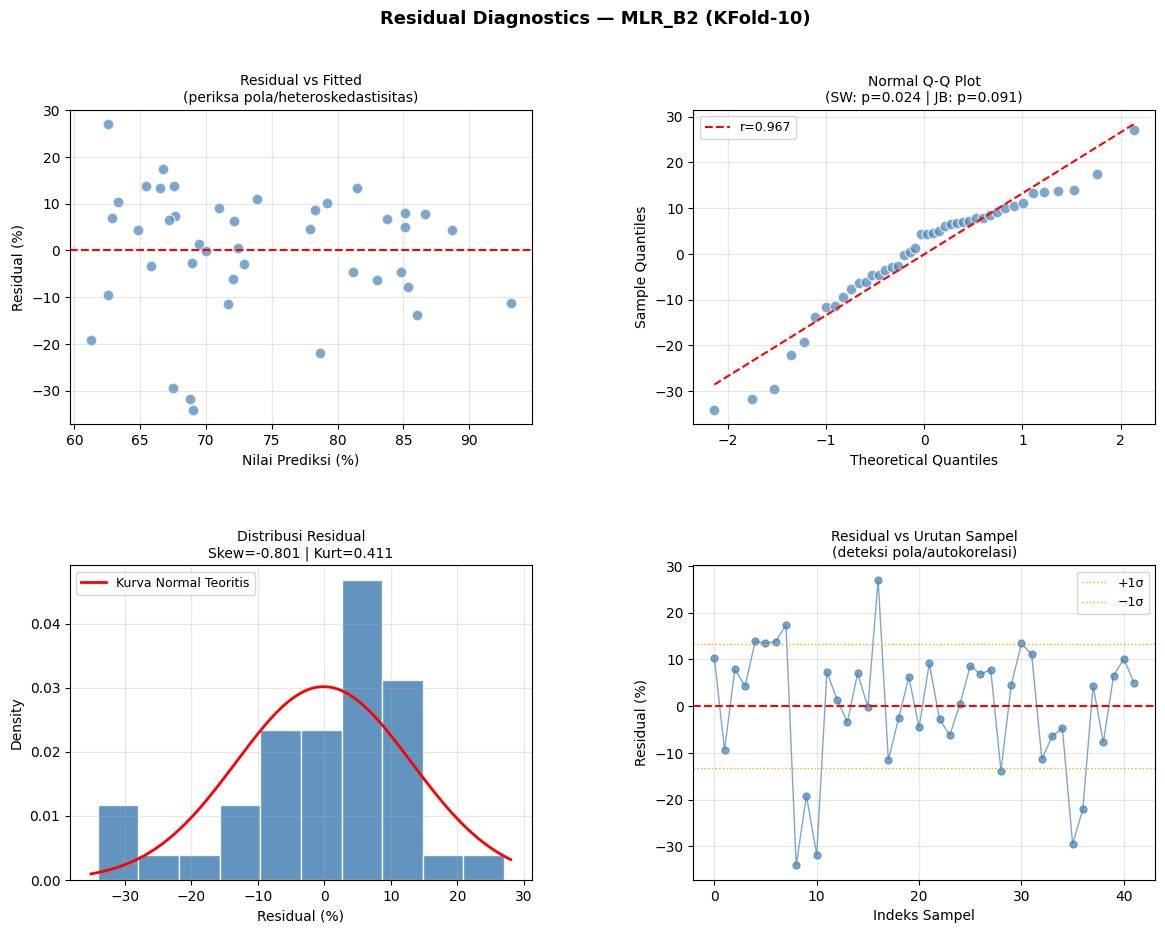


────────────────────────────────────────────────────────────
  MODEL : MLR_B3  |  CV : KFold-10
────────────────────────────────────────────────────────────
  Shapiro-Wilk  : W=0.9605, p=0.1536  ✓ Residual normal
  Jarque-Bera   : stat=2.7585, p=0.2518  ✓ Normal
  Skewness      : -0.6270  (miring sedang)
  Excess Kurt   : 0.0608  (normal)


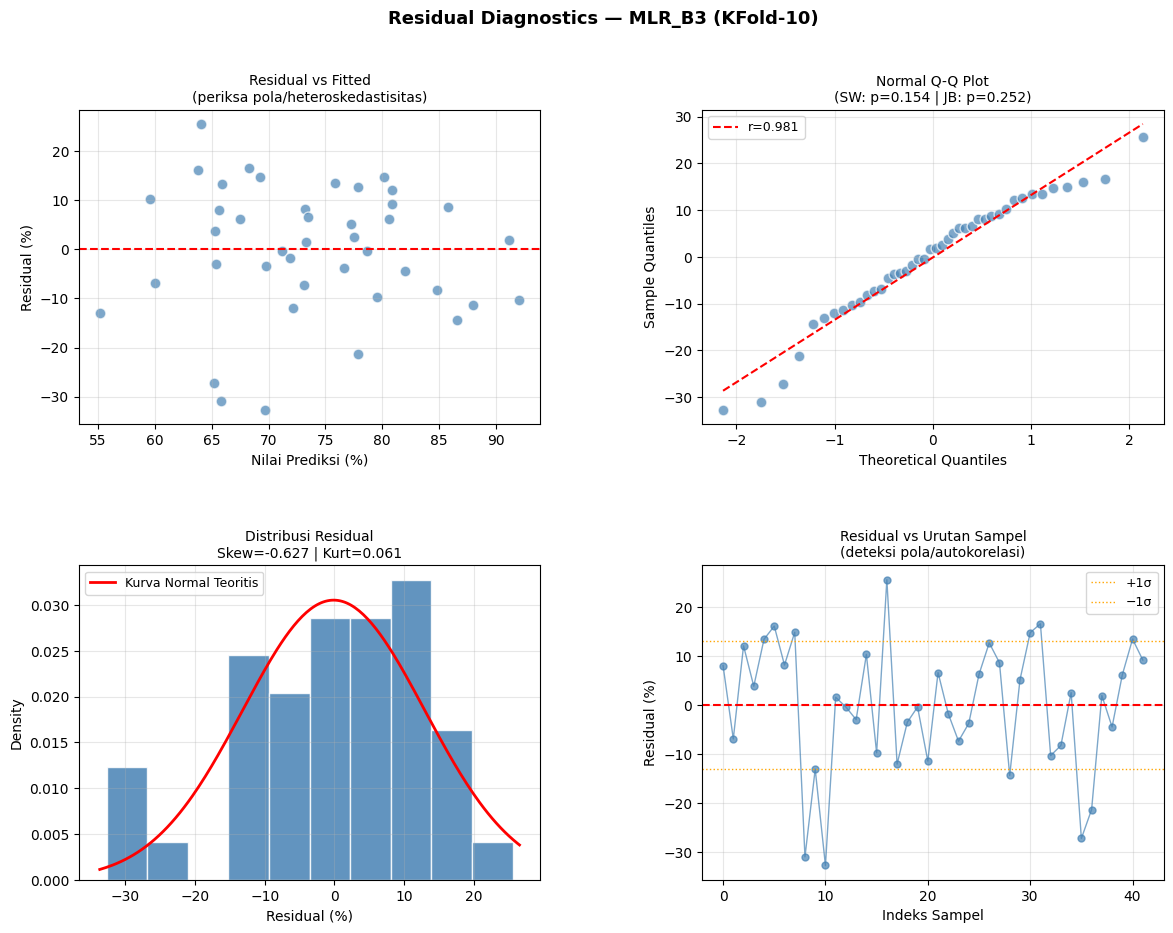


RINGKASAN RESIDUAL DIAGNOSTICS — KFold-5 vs KFold-10
Model        CV             SW p     JB p     Skew Status
-----------------------------------------------------------------
MLR_B2B3     KFold-5      0.0744   0.1723  -0.7021  ✓ Normal
MLR_B2       KFold-5      0.0230   0.0783  -0.8239  ✗ Tdk Normal
MLR_B3       KFold-5      0.1369   0.2304  -0.6471  ✓ Normal
MLR_B2B3     KFold-10     0.0904   0.1990  -0.6735  ✓ Normal
MLR_B2       KFold-10     0.0241   0.0915  -0.8007  ✗ Tdk Normal
MLR_B3       KFold-10     0.1536   0.2518  -0.6270  ✓ Normal


In [11]:
# ============================================================
# SCRIPT TAMBAHAN — RESIDUAL DIAGNOSTICS (KFold-5 & KFold-10)
# Letakkan setelah Section 8 (Ringkasan Perbandingan)
# ============================================================

from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_predict

print("=" * 65)
print("RESIDUAL DIAGNOSTICS — KFold-5 & KFold-10")
print("=" * 65)

# ─── Konfigurasi semua kombinasi model × fold ────────────────
skenario = [
    {'label': 'MLR_B2B3', 'X': X_B2B3, 'kf': KF5,  'kf_label': 'KFold-5'},
    {'label': 'MLR_B2',   'X': X_B2,   'kf': KF5,  'kf_label': 'KFold-5'},
    {'label': 'MLR_B3',   'X': X_B3,   'kf': KF5,  'kf_label': 'KFold-5'},
    {'label': 'MLR_B2B3', 'X': X_B2B3, 'kf': KF10, 'kf_label': 'KFold-10'},
    {'label': 'MLR_B2',   'X': X_B2,   'kf': KF10, 'kf_label': 'KFold-10'},
    {'label': 'MLR_B3',   'X': X_B3,   'kf': KF10, 'kf_label': 'KFold-10'},
]

hasil_residual = {}

for sk in skenario:
    label    = sk['label']
    X        = sk['X']
    kf       = sk['kf']
    kf_label = sk['kf_label']
    key      = f"{label}_{kf_label}"

    model  = LinearRegression()
    Y_pred = cross_val_predict(model, X, Y_raw, cv=kf)
    Y_pred = np.clip(Y_pred, 0, 100)
    resid  = Y_raw - Y_pred

    hasil_residual[key] = resid

    # ── Uji statistik ──────────────────────────────────────────
    sw_stat, sw_p = stats.shapiro(resid)
    jb_stat, jb_p = stats.jarque_bera(resid)
    skewness      = stats.skew(resid)
    kurt          = stats.kurtosis(resid, fisher=True)

    print(f"\n{'─'*60}")
    print(f"  MODEL : {label}  |  CV : {kf_label}")
    print(f"{'─'*60}")
    print(f"  Shapiro-Wilk  : W={sw_stat:.4f}, p={sw_p:.4f}  "
          f"{'✓ Residual normal' if sw_p > 0.05 else '✗ Residual TIDAK normal'}")
    print(f"  Jarque-Bera   : stat={jb_stat:.4f}, p={jb_p:.4f}  "
          f"{'✓ Normal' if jb_p > 0.05 else '✗ Tidak normal'}")
    print(f"  Skewness      : {skewness:.4f}  "
          f"{'(simetris)' if abs(skewness) < 0.5 else '(miring sedang)' if abs(skewness) < 1.0 else '(sangat miring)'}")
    print(f"  Excess Kurt   : {kurt:.4f}  "
          f"{'(normal)' if abs(kurt) < 1.0 else '(leptokurtic/platykurtic)'}")

    # ── Visualisasi 4-panel ────────────────────────────────────
    fig = plt.figure(figsize=(14, 10))
    fig.suptitle(f'Residual Diagnostics — {label} ({kf_label})',
                 fontsize=13, fontweight='bold')
    gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

    # Panel 1: Residual vs Fitted
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.scatter(Y_pred, resid, alpha=0.7, color='steelblue',
                edgecolors='white', s=60)
    ax1.axhline(0, color='red', linestyle='--', linewidth=1.5)
    ax1.set_xlabel('Nilai Prediksi (%)', fontsize=10)
    ax1.set_ylabel('Residual (%)', fontsize=10)
    ax1.set_title('Residual vs Fitted\n(periksa pola/heteroskedastisitas)', fontsize=10)
    ax1.grid(True, alpha=0.3)

    # Panel 2: Q-Q Plot
    ax2 = fig.add_subplot(gs[0, 1])
    (osm, osr), (slope, intercept, r_qq) = stats.probplot(resid, dist='norm')
    ax2.scatter(osm, osr, alpha=0.7, color='steelblue',
                edgecolors='white', s=60)
    x_line = np.array([min(osm), max(osm)])
    ax2.plot(x_line, slope * x_line + intercept,
             'r--', linewidth=1.5, label=f'r={r_qq:.3f}')
    ax2.set_xlabel('Theoretical Quantiles', fontsize=10)
    ax2.set_ylabel('Sample Quantiles', fontsize=10)
    ax2.set_title(f'Normal Q-Q Plot\n(SW: p={sw_p:.3f} | JB: p={jb_p:.3f})', fontsize=10)
    ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)

    # Panel 3: Histogram residual
    ax3 = fig.add_subplot(gs[1, 0])
    ax3.hist(resid, bins=10, color='steelblue', edgecolor='white',
             alpha=0.85, density=True)
    xmin, xmax = resid.min() - 1, resid.max() + 1
    x_norm = np.linspace(xmin, xmax, 200)
    ax3.plot(x_norm,
             stats.norm.pdf(x_norm, resid.mean(), resid.std()),
             'r-', linewidth=2, label='Kurva Normal Teoritis')
    ax3.set_xlabel('Residual (%)', fontsize=10)
    ax3.set_ylabel('Density', fontsize=10)
    ax3.set_title(f'Distribusi Residual\nSkew={skewness:.3f} | Kurt={kurt:.3f}', fontsize=10)
    ax3.legend(fontsize=9); ax3.grid(True, alpha=0.3)

    # Panel 4: Residual vs Urutan Sampel
    ax4 = fig.add_subplot(gs[1, 1])
    ax4.plot(range(len(resid)), resid, 'o-', color='steelblue',
             alpha=0.7, markersize=5, linewidth=1)
    ax4.axhline(0,             color='red',    linestyle='--', linewidth=1.5)
    ax4.axhline( resid.std(),  color='orange', linestyle=':', linewidth=1, label='+1σ')
    ax4.axhline(-resid.std(),  color='orange', linestyle=':', linewidth=1, label='−1σ')
    ax4.set_xlabel('Indeks Sampel', fontsize=10)
    ax4.set_ylabel('Residual (%)', fontsize=10)
    ax4.set_title('Residual vs Urutan Sampel\n(deteksi pola/autokorelasi)', fontsize=10)
    ax4.legend(fontsize=9); ax4.grid(True, alpha=0.3)

    plt.savefig(OUT_DIR + f'residual_diag_{label}_{kf_label}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

# ── Tabel ringkasan semua hasil ────────────────────────────────
print("\n" + "=" * 65)
print("RINGKASAN RESIDUAL DIAGNOSTICS — KFold-5 vs KFold-10")
print("=" * 65)
print(f"{'Model':<12} {'CV':<10} {'SW p':>8} {'JB p':>8} {'Skew':>8} {'Status'}")
print("-" * 65)

for sk in skenario:
    label    = sk['label']
    kf_label = sk['kf_label']
    key      = f"{label}_{kf_label}"
    resid    = hasil_residual[key]

    sw_stat, sw_p = stats.shapiro(resid)
    jb_stat, jb_p = stats.jarque_bera(resid)
    skewness      = stats.skew(resid)
    status        = '✓ Normal' if sw_p > 0.05 else '✗ Tdk Normal'

    print(f"{label:<12} {kf_label:<10} {sw_p:>8.4f} {jb_p:>8.4f} {skewness:>8.4f}  {status}")

## 9. Plot Perbandingan KFold 5 vs KFold 10

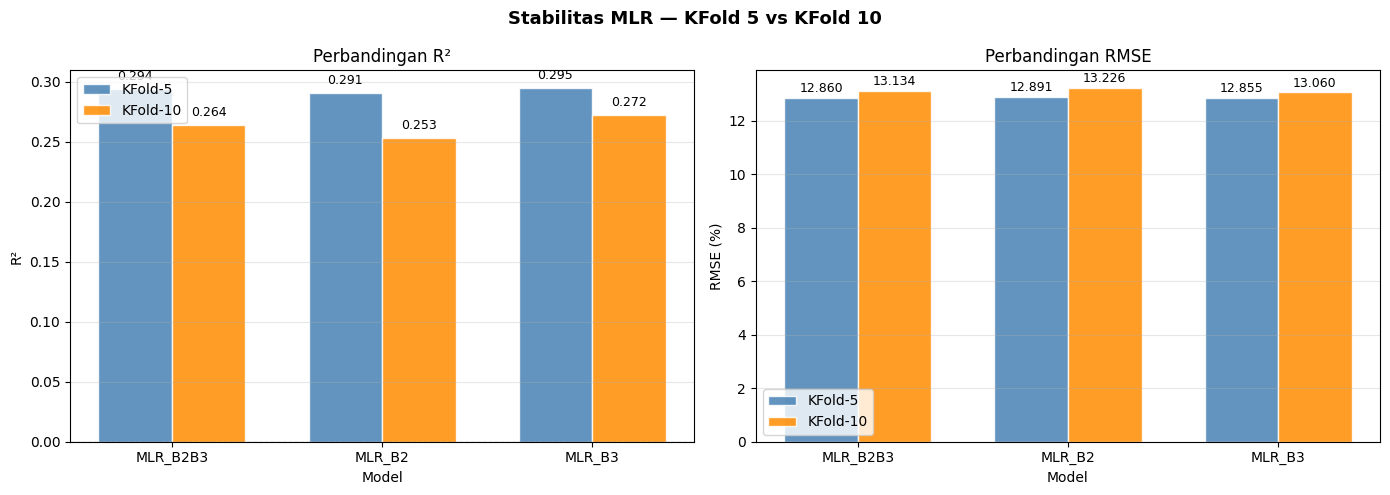

Tersimpan: stabilitas_kfold_mlr.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Stabilitas MLR — KFold 5 vs KFold 10',
             fontsize=13, fontweight='bold')

model_names  = ['MLR_B2B3', 'MLR_B2', 'MLR_B3']
r2_kf5       = [r_B2B3_kf5['r2'],   r_B2_kf5['r2'],   r_B3_kf5['r2']]
r2_kf10      = [r_B2B3_kf10['r2'],  r_B2_kf10['r2'],  r_B3_kf10['r2']]
rmse_kf5     = [r_B2B3_kf5['rmse'], r_B2_kf5['rmse'], r_B3_kf5['rmse']]
rmse_kf10    = [r_B2B3_kf10['rmse'],r_B2_kf10['rmse'],r_B3_kf10['rmse']]

x     = np.arange(len(model_names))
width = 0.35

# Panel kiri — R²
ax = axes[0]
b1 = ax.bar(x - width/2, r2_kf5,  width, label='KFold-5',
            color='steelblue',  edgecolor='white', alpha=0.85)
b2 = ax.bar(x + width/2, r2_kf10, width, label='KFold-10',
            color='darkorange', edgecolor='white', alpha=0.85)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Model'); ax.set_ylabel('R²')
ax.set_title('Perbandingan R²')
ax.set_xticks(x); ax.set_xticklabels(model_names)
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=9)

# Panel kanan — RMSE
ax = axes[1]
b3 = ax.bar(x - width/2, rmse_kf5,  width, label='KFold-5',
            color='steelblue',  edgecolor='white', alpha=0.85)
b4 = ax.bar(x + width/2, rmse_kf10, width, label='KFold-10',
            color='darkorange', edgecolor='white', alpha=0.85)
ax.set_xlabel('Model'); ax.set_ylabel('RMSE (%)')
ax.set_title('Perbandingan RMSE')
ax.set_xticks(x); ax.set_xticklabels(model_names)
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
for bar in list(b3) + list(b4):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.1,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(OUT_DIR + 'stabilitas_kfold_mlr.png', dpi=150, bbox_inches='tight')
plt.show()
print('Tersimpan: stabilitas_kfold_mlr.png')